In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

np.random.seed(42)
n = 500

mileage_km = np.random.normal(60000, 25000, n)
age_years = np.random.randint(1, 15, n)
engine_size_L = np.random.uniform(1.0, 5.0, n)
price = np.random.normal(800000, 250000, n)
fuel_type = np.random.choice(["Petrol", "Diesel", "Electric"], n)

messy = pd.DataFrame({
    "mileage_km": mileage_km,
    "age_years": age_years,
    "engine_size_L": engine_size_L,
    "price": price,
    "fuel_type": fuel_type
})

messy.loc[[10, 25, 50, 100], "mileage_km"] = np.nan
messy.loc[[15, 40, 80], "age_years"] = np.nan
messy.loc[[20, 60, 120], "engine_size_L"] = np.nan
messy.loc[[30, 70, 150], "price"] = np.nan
messy.loc[[35, 90, 180], "fuel_type"] = np.nan

messy.loc[[5, 6], "price"] = [5000000, 6000000]
messy.loc[[7, 8], "mileage_km"] = [300000, 350000]

display(messy.head())

,mileage_km,age_years,engine_size_L,price,fuel_type
0,72417.853825,10.0,4.260218,616828.952186,Electric
1,56543.392471,2.0,2.992363,926356.786656,Diesel
2,76192.213453,11.0,1.268702,949998.551981,Electric
3,98075.746410,8.0,2.620992,597481.728948,Diesel
4,54146.165632,11.0,2.989860,685390.764953,Electric


In [2]:
clean = messy.copy()
num_cols = ["mileage_km", "age_years", "engine_size_L", "price"]
cat_cols = ["fuel_type"]

def cap_outliers_iqr(df, col, k=1.5):
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    mask = (df[col] < lower) | (df[col] > upper)
    count = int(mask.sum())
    df[col] = df[col].clip(lower, upper)
    return count

for col in ["price", "mileage_km"]:
    print(f"{col} outliers capped:", cap_outliers_iqr(clean, col))

price outliers capped: 4
mileage_km outliers capped: 6


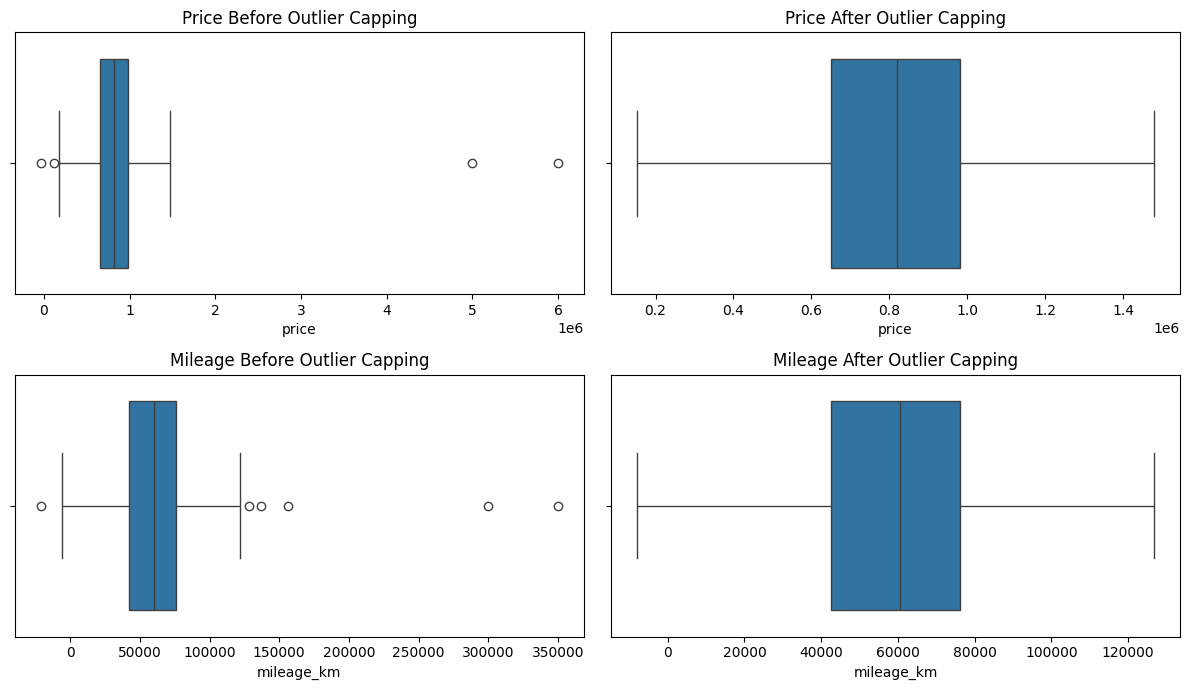

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
sns.boxplot(x=messy["price"], ax=axes[0,0]); axes[0,0].set_title("Price Before Outlier Capping")
sns.boxplot(x=clean["price"], ax=axes[0,1]); axes[0,1].set_title("Price After Outlier Capping")
sns.boxplot(x=messy["mileage_km"], ax=axes[1,0]); axes[1,0].set_title("Mileage Before Outlier Capping")
sns.boxplot(x=clean["mileage_km"], ax=axes[1,1]); axes[1,1].set_title("Mileage After Outlier Capping")
plt.tight_layout()
plt.show()

In [4]:
num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

clean[num_cols] = num_imputer.fit_transform(clean[num_cols])
clean[cat_cols] = cat_imputer.fit_transform(clean[cat_cols])

print("Missing values after cleaning:")
display(clean.isna().sum())

Missing values after cleaning:


,0
mileage_km,0
age_years,0
engine_size_L,0
price,0
fuel_type,0


In [5]:
encoder = OneHotEncoder(sparse_output=False, drop="first")
fuel_encoded = pd.DataFrame(
    encoder.fit_transform(clean[["fuel_type"]]),
    columns=encoder.get_feature_names_out(["fuel_type"])
)
display(fuel_encoded.head())

,fuel_type_Electric,fuel_type_Petrol
0,1.0,0.0
1,0.0,0.0
2,1.0,0.0
3,0.0,0.0
4,1.0,0.0


In [6]:
scaler = StandardScaler()
scaled_num = pd.DataFrame(
    scaler.fit_transform(clean[num_cols]),
    columns=num_cols
)

processed_df = pd.concat([scaled_num, fuel_encoded], axis=1)
display(processed_df.head())

,mileage_km,age_years,engine_size_L,price,fuel_type_Electric,fuel_type_Petrol
0,0.489856,0.679019,1.090455,-0.785372,1.0,0.0
1,-0.159518,-1.309323,-0.001869,0.465836,0.0,0.0
2,0.644254,0.927561,-1.486894,0.561403,1.0,0.0
3,1.539440,0.181933,-0.321824,-0.863580,0.0,0.0
4,-0.257581,0.927561,-0.004026,-0.508224,1.0,0.0


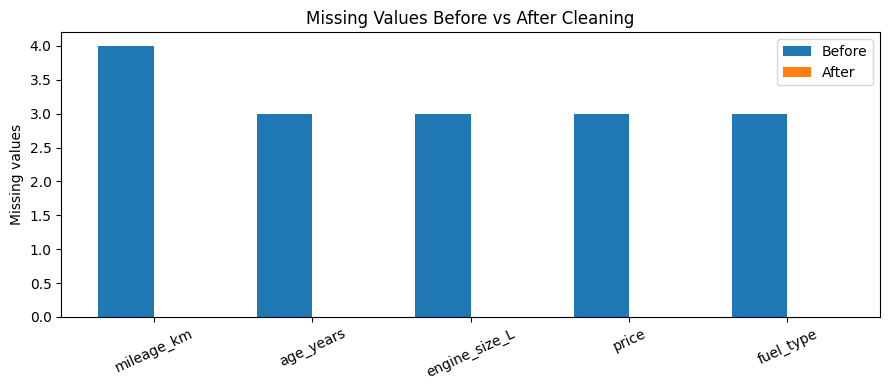

In [7]:
fig, ax = plt.subplots(figsize=(9,4))
before = messy.isna().sum()
after = clean.isna().sum()
x = np.arange(len(before))
w = 0.35
ax.bar(x-w/2, before.values, width=w, label="Before")
ax.bar(x+w/2, after.values, width=w, label="After")
ax.set_xticks(x)
ax.set_xticklabels(before.index, rotation=25)
ax.set_ylabel("Missing values")
ax.set_title("Missing Values Before vs After Cleaning")
ax.legend()
plt.tight_layout()
plt.show()